### Synthetic Data



In [76]:
#imports
import numpy as np
import plotly.express as px

Create Linear Trend

In [77]:
linear_trend = np.arange(0,356*2) # Values from 0 to 711
fig = px.line(linear_trend, title='Linear Trend')
fig.show()

Introduce Seasonality

In [ ]:
seasonality = 20 * np.sin(2 * np.pi * np.arange(0, 356*2) / 30)
# amplitude * sin(2π * time (711 days) / period (30 days))
fig = px.line(seasonality, title=' Seasonality')
fig.show()

In [79]:
# now add them together
combined = linear_trend + seasonality * 40
fig = px.line(combined, title='Combined Linear Trend and Seasonality')       
fig.show()

In [80]:
# we can also multiply them
combined_mult = linear_trend * (1 + seasonality / 100)
fig = px.line(combined_mult, title='Combined Linear Trend and Seasonality (Multiplicative)')
fig.show()

Noise


In [81]:
# simple random noise
noise = np.random.normal(0, 100, size=712)
fig = px.line(noise, title='Random Noise')
fig.show()      

In [82]:
# add noise to the additive series
noisy_series = combined + noise*3
fig = px.line(noisy_series, title='Additive Series with Noise')
fig.show()

In [83]:
noisy_series_mult = combined_mult + noise*.5

fig = px.line(noisy_series_mult, title='Multiplicative Series with Noise')
fig.show()

In [84]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller


Analyze Data

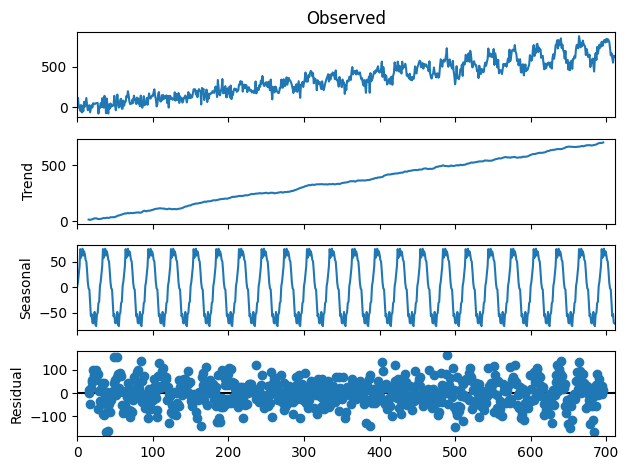

In [85]:
result = seasonal_decompose(noisy_series_mult, model='additive', period=30)
result.plot();

Test for Stationarity

In [86]:
result = adfuller(noisy_series_mult)
print('p-value:', result[1])


p-value: 0.8483151326801506


Very high p-value -> non-stationary <br>
Remove stationarity with differencing:

In [87]:
diff = [noisy_series_mult[i] - noisy_series_mult[i-1] for i in range(1, len(noisy_series_mult))]

fig_diff = px.line(diff, title='Differenced Multiplicative Series with Noise')
fig_diff.show()

In [88]:
result = adfuller(diff)
print('p-value:', result[1])


p-value: 1.8112696496142917e-27


Very low p-value -> stationary series

In [89]:
window = 100
smoothed = np.convolve(diff, np.ones(window)/window, mode='valid')

fig_smooth = px.line(smoothed, title='Smoothed Differenced Series')
fig_smooth.show()